**Predizione di uno "score" di recupero per atleti in base alle abitudini, dati biometrici e performance**

Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26:
Alan Barzanti, Marco Mondardini

L'obiettivo di questo progetto è ottenere una predizione di un livello di recupero dopo un allenamento, attraverso un punteggio da 0 a 100, basandosi su dati biometrici, tipologia di allenamento, abitudini dell'atleta. 

Il dataset include poco più di 8000 istanze e 19 colonne: ogni riga rappresenta un atleta e ogni colonna fornisce un valore sullo specifico dato.

**Introduzione**

Procediamo al caricamento delle librerie fondamendali e del dataset:

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

import os.path

file = "./athlete_recovery_synthetic.csv";
if not os.path.exists(file):
    print("The dataset is missing.");

data = pd.read_csv(file);

Prima di tutto analizziamo il significato di ogni colonna:
- `Athlete_ID` — Identificativo univoco dell' atleta *(indice, sarà da escludere)*
- `Day` — Il giorno del mese *(numerica continua)*, da 1 a 28.
- `Day_of_Week` — Giorno della settimana da 1 a 7 .
- `Week` — Numero della settimana del mese da 1 a 4.
- `Age` — Età dell'atleta *(numerica continua)*, espressa in anni, da 18 a 41.
- `Gender` — Genere dell'atleta *(categorica: Male / Female / Non-binary)*.
- `Sport_Type` — Tipo di sport dell'atleta *(categorica: Team Sport, Endurance, Strength)*.
- `Training_Type` — Tipo specifico dell'allenamento *(categorica: HIIT, Cardio, Rest, Strength)*.
- `Training_Duration_Min` — Durata dell'allenamento in minuti.
- `Training_Intensity` — Intensità dell'allenamento, soggettiva o misurata, in un range da 1.0 a 10.0.
- `Sleep_Duration_Hours` — Ore di sonno della notte precedente all'allenamento *(numerica continua)*.
- `Caffeine_Intake_mg` — Caffeina assunta durante il giorno in milligrammi.
- `Stress_Level` — Livello di stress *(categorica ordinale: Low / Medium / High)*.
- `Resting_Heart_Rate` — Battiti del cuore a riposo in battiti per minuto (BPM).
- `HRV_ms` — Variabilità della frequenza cardiaca misurata in millisecondi.
- `Mood_Score` — Livello del morale da 1.0 a 10.0.
- `Muscle_Soreness` — Livello di dolore muscolare da 1.0 a 10.0.
- `Energy_Level` — Livello di energia percepita da 1.0 a 10.0
- `Recovery_Score` — Punteggio complessivo da 0.0 a 100.0 che indica la condizione fisica generale dell'atleta.

In [5]:
data.head(1)

,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
0,1000,1,1,1,28,Male,Team Sport,HIIT,46,7.9,7.7,270,High,59,75,4.3,4.8,5.9,51.1


In [6]:
data.info(verbose=False, memory_usage="deep");

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8379 entries, 0 to 8378
Columns: 19 entries, Athlete_ID to Recovery_Score
dtypes: float64(6), int64(9), object(4)
memory usage: 2.7 MB


Come possiamo vedere al momento l'utilizzo della memoria è di 2.7MB, ma possiamo ottimizzarlo:

In [7]:
data['Gender'] = data['Gender'].astype("category")
data['Sport_Type'] = data['Sport_Type'].astype("category")
data['Training_Type'] = data['Training_Type'].astype("category")
data['Stress_Level'] = data['Stress_Level'].astype("category")
data = data.drop(columns=["Athlete_ID"])

In [8]:
data.info(verbose=False, memory_usage="deep");

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8379 entries, 0 to 8378
Columns: 18 entries, Day to Recovery_Score
dtypes: category(4), float64(6), int64(8)
memory usage: 950.7 KB


**Analisi esplorativa dei dati:**

In [9]:
data.describe()

,Day,Day_of_Week,Week,Age,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
count,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8378.000000,7775.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000
mean,14.497076,3.998329,2.499821,25.860962,52.789712,6.211506,7.498842,185.348132,57.202888,74.126507,5.177109,5.161953,3.273087,49.061356
std,8.078044,2.000417,1.117941,4.531092,21.357704,2.368960,0.693790,112.850208,5.790991,13.981632,1.210072,2.127583,1.679100,27.926347
min,1.000000,1.000000,1.000000,18.000000,10.000000,1.000000,5.000000,0.000000,38.000000,22.000000,1.000000,1.000000,1.000000,0.000000
25%,8.000000,2.000000,2.000000,23.000000,36.000000,4.900000,7.000000,126.000000,53.000000,64.000000,4.400000,3.600000,2.000000,27.800000
50%,14.000000,4.000000,2.000000,26.000000,56.000000,6.600000,7.500000,212.000000,58.000000,74.000000,5.200000,5.200000,3.100000,48.900000
75%,21.000000,6.000000,3.000000,28.000000,69.000000,7.900000,8.000000,268.000000,61.000000,84.000000,6.000000,6.700000,4.300000,69.900000
max,28.000000,7.000000,4.000000,41.000000,115.000000,10.000000,9.500000,400.000000,81.000000,115.000000,9.500000,10.000000,10.000000,100.000000


Osserviamo come sono distribuiti i punteggi:

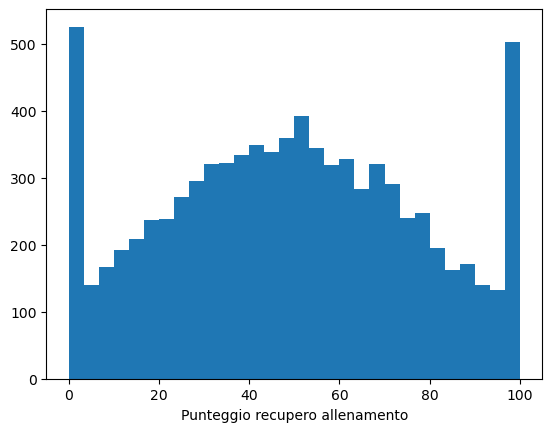

In [10]:
plt.hist(data["Recovery_Score"], bins=30)
plt.xlabel("Punteggio recupero allenamento")
plt.show()

Notiamo che ci sono due picchi agli estremi con i punteggi 0 e 100.
Notiamo inoltre una distribuzione gaussiana con un picco intorno al valore 55 per poi scendere di nuovo.

Osserviamo alcuni fattori che correlazione hanno con il punteggio finale:

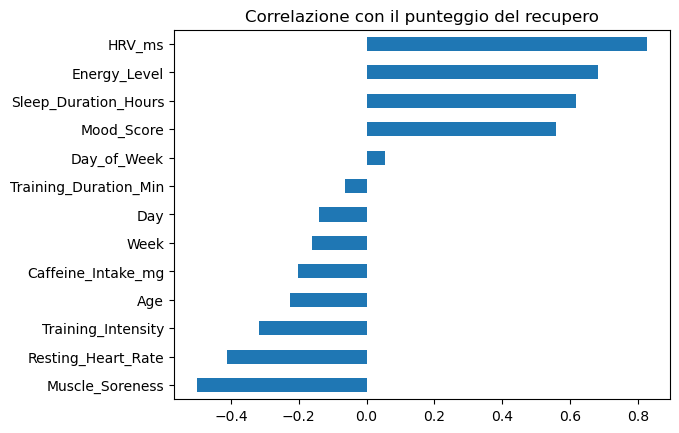

In [12]:
df_numeric = data.select_dtypes(include="number")
corr = df_numeric.corr()["Recovery_Score"].drop("Recovery_Score").sort_values()
corr.plot(kind="barh")
plt.title("Correlazione con il punteggio del recupero")
plt.show()

Notiamo che la frequenza cardiaca a l'impatto più positivo sul punteggio finale, mentre il dolore ai muscoli ha l'impatto maggiormente negativo.
Come spesso si sente il sonno ha un ruolo fondamentale nel recupero e notiamo che al il morale è molto importante.
Possiamo notare come l'intensità dell'allenamento, insieme all'età influenzano negativamente il recupero dell'atleta.

Proviamo ad analizzare tramite dei grafici a dispersione le variabili con una correlazione maggiore:

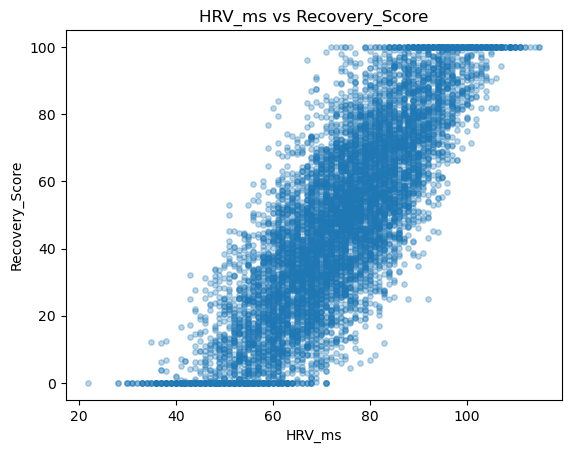

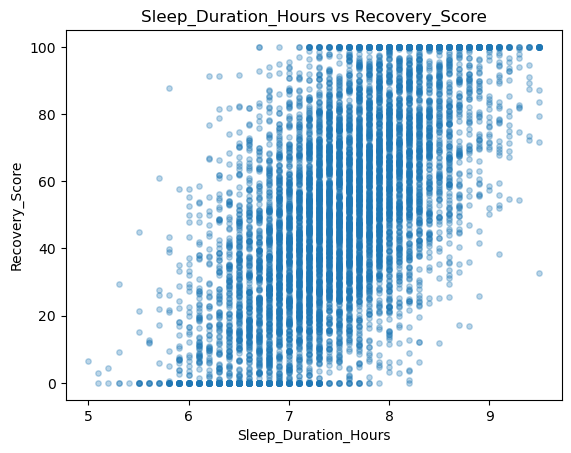

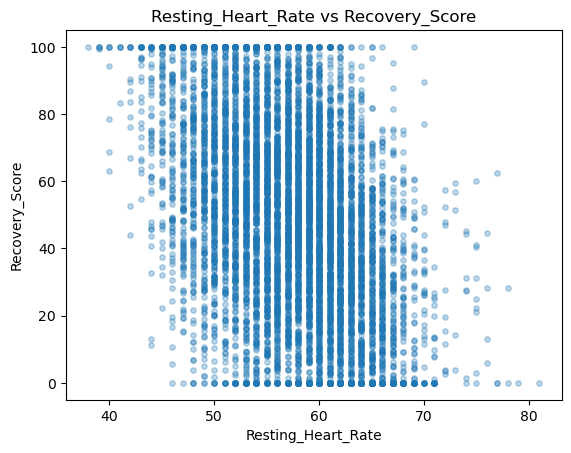

In [13]:
for col in ["HRV_ms", "Sleep_Duration_Hours", "Resting_Heart_Rate"]:
    plt.scatter(data[col], data["Recovery_Score"], alpha=0.3, s=15)
    plt.xlabel(col)
    plt.ylabel("Recovery_Score")
    plt.title(f"{col} vs Recovery_Score")
    plt.show()